<a href="https://colab.research.google.com/github/onatsf/GalatasarayEDA/blob/main/Onat_Safak_Galatasaray_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Galatasaray S.K. — Exploratory Data Analysis
### Süper Lig Performance (2011–2026)

**Author:** Onat Safak  
**Date:** March 2026  
**Data Source:** API-Football(https://www.api-football.com/)

---

## Project Overview

This notebook performs an exploratory data analysis of **Galatasaray S.K.'s** performance
in the Turkish Süper Lig across fifteen seasons (2010/11 through 2025/26). We examine:

1. **Season-over-season performance trends:** wins, goals, points accumulation  
2. **Home vs. away dynamics:** how venue impacts results and playing style  
3. **Rivalry deep dive:** head-to-head records vs. Fenerbahçe, Beşiktaş, and Trabzonspor  
4. **Player contributions:** who drives the team's success
6. **Final stretch:** do championship seasons finish stronger?  

The data is collected via the API-Football.

---
## 1. Setup & Imports

In [ ]:
#import all the stuff that might be used
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Galatasaray brand colors
GS_YELLOW = '#FDB913'
GS_RED = '#A90432'

---
## 2. Data Collection from API-Football


In [ ]:
# API configuration
API_KEY = 'a3484c435c6442bb814ce783b44d379b'
BASE_URL = 'https://v3.football.api-sports.io'
HEADERS = {'x-apisports-key': API_KEY}

#IDs for Galatasaray and Turkish Super Lig
TEAM_ID = 645
LEAGUE_ID = 203
SEASONS = list(range(2010, 2026))

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

### 2.1 Collect Match Fixtures

In [ ]:
all_fixtures = []

for season in SEASONS:
    url = f'{BASE_URL}/fixtures'
    params = {'team': TEAM_ID, 'league': LEAGUE_ID, 'season': season}
    response = requests.get(url, headers=HEADERS, params=params)
    data = response.json()['response']

    #getting all the data from the API and storing it, this allows us the work with the data more easily.
    for match in data:
        all_fixtures.append({
            'fixture_id': match['fixture']['id'],
            'date': match['fixture']['date'][:10],
            'season': season,
            'round': match['league']['round'],
            'referee': match['fixture'].get('referee'),
            'venue': match['fixture']['venue']['name'],
            'home_team': match['teams']['home']['name'],
            'away_team': match['teams']['away']['name'],
            'home_goals': match['goals']['home'],
            'away_goals': match['goals']['away'],
            'ht_home': match['score']['halftime']['home'],
            'ht_away': match['score']['halftime']['away'],
        })
    time.sleep(0.3)

fixtures_df = pd.DataFrame(all_fixtures)
fixtures_df.to_csv(os.path.join(DATA_DIR, 'gs_fixtures_raw.csv'), index=False)
print(f'Collected {len(fixtures_df)} fixtures across {len(SEASONS)} seasons')
fixtures_df.head()

Collected 534 fixtures across 16 seasons


,fixture_id,date,season,round,referee,venue,home_team,away_team,home_goals,away_goals,ht_home,ht_away
0,509614,2012-04-16,2011,Championship Group - 1,None,FIYAPI Inönü Stadyumu,Beşiktaş,Galatasaray,0.0,2.0,0.0,1.0
1,509616,2012-04-22,2011,Championship Group - 2,None,Türk Telekom Arena,Galatasaray,Fenerbahçe,1.0,2.0,0.0,1.0
2,509617,2012-04-28,2011,Championship Group - 3,None,Hüseyin Avni Aker Stadyumu,Trabzonspor,Galatasaray,2.0,4.0,0.0,3.0
3,509619,2012-05-02,2011,Championship Group - 4,None,Türk Telekom Arena,Galatasaray,Trabzonspor,0.0,0.0,0.0,0.0
4,509622,2012-05-06,2011,Championship Group - 5,None,Türk Telekom Arena,Galatasaray,Beşiktaş,2.0,2.0,2.0,0.0


### 2.2 Collect Match Statistics

For each fixture we pull possession, shots, fouls, corners, etc.

In [ ]:
all_stats = []

for fid in fixtures_df['fixture_id']:
    url = f'{BASE_URL}/fixtures/statistics'
    response = requests.get(url, headers=HEADERS, params={'fixture': fid})
    data = response.json()['response']

    gs_stats, opp_stats = {}, {}
    for team_data in data:
        stats_dict = {s['type']: s['value'] for s in team_data['statistics']}
        if 'Galatasaray' in team_data['team']['name']:
            gs_stats = stats_dict
        else:
            opp_stats = stats_dict
    #we are adding spesific statistics to the dictionary, so we will have easier access to all of them when analyzing
    all_stats.append({
        'fixture_id': fid,
        'gs_shots': gs_stats.get('Total Shots'),
        'gs_shots_on': gs_stats.get('Shots on Goal'),
        'gs_possession': gs_stats.get('Ball Possession'),
        'gs_passes': gs_stats.get('Total passes'),
        'gs_pass_acc': gs_stats.get('Passes accurate'),
        'gs_fouls': gs_stats.get('Fouls'),
        'gs_corners': gs_stats.get('Corner Kicks'),
        'gs_yellows': gs_stats.get('Yellow Cards'),
        'gs_reds': gs_stats.get('Red Cards'),
        'gs_offsides': gs_stats.get('Offsides'),
        'opp_shots': opp_stats.get('Total Shots'),
        'opp_shots_on': opp_stats.get('Shots on Goal'),
        'opp_possession': opp_stats.get('Ball Possession'),
        'opp_fouls': opp_stats.get('Fouls'),
        'opp_corners': opp_stats.get('Corner Kicks'),
    })
    time.sleep(0.3)
#A dataframe is created with all the statistics. It is important to note that some statistics started to be calculated after several years, so they are missing in the beginning.
stats_df = pd.DataFrame(all_stats)
stats_df.to_csv(os.path.join(DATA_DIR, 'gs_match_stats.csv'), index=False)
print(f'Collected stats for {len(stats_df)} matches')
stats_df.head()

Collected stats for 534 matches


,fixture_id,gs_shots,gs_shots_on,gs_possession,gs_passes,gs_pass_acc,gs_fouls,gs_corners,gs_yellows,gs_reds,gs_offsides,opp_shots,opp_shots_on,opp_possession,opp_fouls,opp_corners
0,509614,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN
1,509616,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN
2,509617,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN
3,509619,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN
4,509622,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN


### 2.3 Collect Player Statistics

In [ ]:
all_players = []

for season in SEASONS:
    page = 1
    while True:
        url = f'{BASE_URL}/players'
        params = {'team': TEAM_ID, 'season': season, 'league': LEAGUE_ID, 'page': page}
        response = requests.get(url, headers=HEADERS, params=params)
        data = response.json()
        results = data.get('response', [])

        if not results:
            break

        for item in results:
            player = item['player']
            for s in item['statistics']:
                if s['league']['id'] != LEAGUE_ID:
                    continue
                all_players.append({
                    'season': season,
                    'player_id': player['id'],
                    'name': player['name'],
                    'age': player.get('age'),
                    'nationality': player.get('nationality'),
                    'position': s['games'].get('position'),
                    'appearances': s['games'].get('appearences'),
                    'lineups': s['games'].get('lineups'),
                    'minutes': s['games'].get('minutes'),
                    'rating': s['games'].get('rating'),
                    'goals': s['goals'].get('total'),
                    'assists': s['goals'].get('assists'),
                    'key_passes': s['passes'].get('key'),
                    'pass_accuracy': s['passes'].get('accuracy'),
                    'total_shots': s['shots'].get('total'),
                    'tackles': s['tackles'].get('total'),
                    'yellow_cards': s['cards'].get('yellow'),
                    'red_cards': s['cards'].get('red'),
                })

        if page >= data['paging']['total']:
            break
        page += 1
        time.sleep(0.3)

players_df = pd.DataFrame(all_players)
players_df.to_csv(os.path.join(DATA_DIR, 'gs_players.csv'), index=False)
print(f'Collected {len(players_df)} player-season records')
players_df.head()

Collected 638 player-season records


,season,player_id,name,age,nationality,position,appearances,lineups,minutes,rating,goals,assists,key_passes,pass_accuracy,total_shots,tackles,yellow_cards,red_cards
0,2011,245145,Aykut Erçetin,33.0,Turkey,Goalkeeper,1.0,1.0,90.0,None,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2011,138967,Yiğit İsmail Gökoğlan,34.0,Turkey,Midfielder,8.0,0.0,172.0,None,1.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2011,50197,S. Kurtuluş,31.0,Turkey,Defender,0.0,0.0,0.0,None,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2011,44490,E. Çolak,32.0,Türkiye,Midfielder,29.0,24.0,1924.0,None,3.0,NaN,NaN,NaN,NaN,NaN,6.0,0.0
4,2011,449,S. İnan,35.0,Turkey,Midfielder,39.0,39.0,3485.0,None,13.0,NaN,NaN,NaN,NaN,NaN,4.0,0.0


---
## 3. Data Cleaning & Preparation

In [ ]:
# Merge fixtures with match statistics
df = fixtures_df.merge(stats_df, on='fixture_id', how='left')

# Galatasaray perspective
df['is_home'] = df['home_team'].str.contains('Galatasaray', case=False, na=False)
df['gs_goals'] = df.apply(lambda r: r['home_goals'] if r['is_home'] else r['away_goals'], axis=1)
df['opp_goals'] = df.apply(lambda r: r['away_goals'] if r['is_home'] else r['home_goals'], axis=1)
df['opponent'] = df.apply(lambda r: r['away_team'] if r['is_home'] else r['home_team'], axis=1)

# Result and points
df['result'] = df.apply(lambda r: 'W' if r['gs_goals'] > r['opp_goals']
                        else ('L' if r['gs_goals'] < r['opp_goals'] else 'D'), axis=1)
df['points'] = df['result'].map({'W': 3, 'D': 1, 'L': 0})
df['goal_diff'] = df['gs_goals'] - df['opp_goals']

# Clean possession (remove % sign)
for col in ['gs_possession', 'opp_possession']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('%', ''), errors='coerce')

# Convert numeric columns
num_cols = ['gs_shots', 'gs_shots_on', 'gs_passes', 'gs_pass_acc', 'gs_fouls',
            'gs_corners', 'gs_yellows', 'gs_reds', 'gs_offsides',
            'opp_shots', 'opp_shots_on', 'opp_fouls', 'opp_corners']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Labels
df['season_label'] = df['season'].apply(lambda x: f'{x}/{x+1}')
df['date'] = pd.to_datetime(df['date'])
df['venue_label'] = df['is_home'].map({True: 'Home', False: 'Away'})

# Derby flag
rivals = ['Fenerbahce', 'Fenerbahçe', 'Besiktas', 'Beşiktaş', 'Trabzonspor']
df['is_derby'] = df['opponent'].apply(
    lambda x: any(r.lower() in str(x).lower() for r in rivals)
)

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset: 534 rows × 37 columns


,fixture_id,date,season,round,referee,venue,home_team,away_team,home_goals,away_goals,...,is_home,gs_goals,opp_goals,opponent,result,points,goal_diff,season_label,venue_label,is_derby
0,509614,2012-04-16,2011,Championship Group - 1,None,FIYAPI Inönü Stadyumu,Beşiktaş,Galatasaray,0.0,2.0,...,False,2.0,0.0,Beşiktaş,W,3,2.0,2011/2012,Away,True
1,509616,2012-04-22,2011,Championship Group - 2,None,Türk Telekom Arena,Galatasaray,Fenerbahçe,1.0,2.0,...,True,1.0,2.0,Fenerbahçe,L,0,-1.0,2011/2012,Home,True
2,509617,2012-04-28,2011,Championship Group - 3,None,Hüseyin Avni Aker Stadyumu,Trabzonspor,Galatasaray,2.0,4.0,...,False,4.0,2.0,Trabzonspor,W,3,2.0,2011/2012,Away,True
3,509619,2012-05-02,2011,Championship Group - 4,None,Türk Telekom Arena,Galatasaray,Trabzonspor,0.0,0.0,...,True,0.0,0.0,Trabzonspor,D,1,0.0,2011/2012,Home,True
4,509622,2012-05-06,2011,Championship Group - 5,None,Türk Telekom Arena,Galatasaray,Beşiktaş,2.0,2.0,...,True,2.0,2.0,Beşiktaş,D,1,0.0,2011/2012,Home,True


In [ ]:
# Overview of the dataset
print(df.dtypes)
print()
print(df.describe())

fixture_id                 int64
date              datetime64[ns]
season                     int64
round                     object
referee                   object
venue                     object
home_team                 object
away_team                 object
home_goals               float64
away_goals               float64
ht_home                  float64
ht_away                  float64
gs_shots                 float64
gs_shots_on              float64
gs_possession            float64
gs_passes                float64
gs_pass_acc              float64
gs_fouls                 float64
gs_corners               float64
gs_yellows               float64
gs_reds                  float64
gs_offsides              float64
opp_shots                float64
opp_shots_on             float64
opp_possession           float64
opp_fouls                float64
opp_corners              float64
is_home                     bool
gs_goals                 float64
opp_goals                float64
opponent  

In [ ]:
# Matches per season
df.groupby('season_label').size()

,0
season_label,
2011/2012,40
2012/2013,34
2013/2014,34
2014/2015,34
2015/2016,34
2016/2017,34
2017/2018,34
2018/2019,34
2019/2020,34


---
## 4. Season-over-Season Performance Trends

The season to season trends gives us a basic understanding of the last 15 seasons of Galatasaray. Also, having a general sense of numbers also makes it easier to understand the data.

In [59]:
# Season aggregates
season_agg = df.groupby('season_label').agg(
    matches=('fixture_id', 'count'),
    wins=('result', lambda x: (x == 'W').sum()),
    draws=('result', lambda x: (x == 'D').sum()),
    losses=('result', lambda x: (x == 'L').sum()),
    total_points=('points', 'sum'),
    goals_scored=('gs_goals', 'sum'),
    goals_conceded=('opp_goals', 'sum'),
    avg_possession=('gs_possession', 'mean'),
).reset_index()
print('Table 1: Season Overviews')
season_agg['win_rate'] = (season_agg['wins'] / season_agg['matches'] * 100).round(1)
season_agg['goal_diff'] = season_agg['goals_scored'] - season_agg['goals_conceded']
season_agg

Table 1: Season Overviews


,season_label,matches,wins,draws,losses,total_points,goals_scored,goals_conceded,avg_possession,win_rate,goal_diff
0,2011/2012,40,25,11,4,86,78.0,30.0,NaN,62.5,48.0
1,2012/2013,34,21,8,5,71,66.0,35.0,NaN,61.8,31.0
2,2013/2014,34,18,11,5,65,59.0,32.0,NaN,52.9,27.0
3,2014/2015,34,24,5,5,77,60.0,35.0,NaN,70.6,25.0
4,2015/2016,34,13,12,9,51,69.0,49.0,57.088235,38.2,20.0
5,2016/2017,34,20,4,10,64,65.0,40.0,60.970588,58.8,25.0
6,2017/2018,34,24,3,7,75,75.0,33.0,57.147059,70.6,42.0
7,2018/2019,34,20,9,5,69,72.0,36.0,57.705882,58.8,36.0
8,2019/2020,34,15,11,8,56,55.0,37.0,59.823529,44.1,18.0
9,2020/2021,40,26,6,8,84,80.0,36.0,57.375000,65.0,44.0


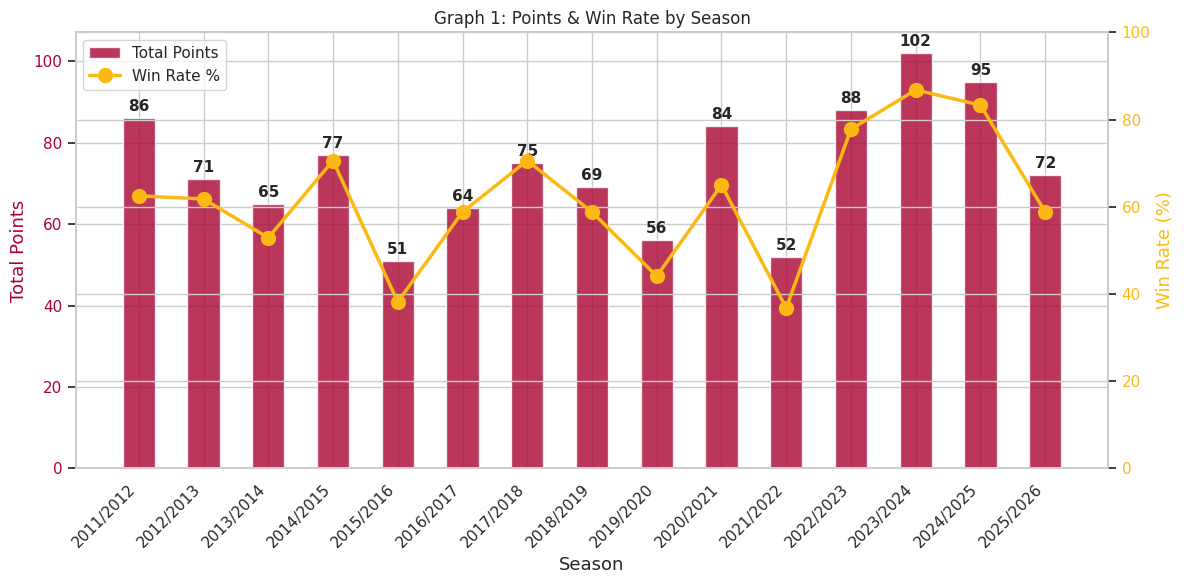

In [60]:
# Figure 1: Points & Win Rate per season (dual axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(season_agg))
bars = ax1.bar(x, season_agg['total_points'], color=GS_RED, alpha=0.8, label='Total Points', width=0.5)
ax1.set_xlabel('Season', fontsize=13)
ax1.set_ylabel('Total Points', fontsize=13, color=GS_RED)
ax1.set_xticks(x)
ax1.set_xticklabels(season_agg['season_label'], fontsize=11)
ax1.tick_params(axis='y', labelcolor=GS_RED)

# Add value labels on bars
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2 = ax1.twinx()
ax2.plot(x, season_agg['win_rate'], color=GS_YELLOW, marker='o', linewidth=2.5,
         markersize=10, label='Win Rate %', zorder=5)
ax2.set_ylabel('Win Rate (%)', fontsize=13, color=GS_YELLOW)
ax2.tick_params(axis='y', labelcolor=GS_YELLOW)
ax1.set_xticklabels(season_agg['season_label'], rotation=45, ha='right')
ax2.set_ylim(0, 100)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.title('Graph 1: Points & Win Rate by Season')
plt.tight_layout()
plt.savefig('fig1_points_winrate.png', dpi=150, bbox_inches='tight')
plt.show()

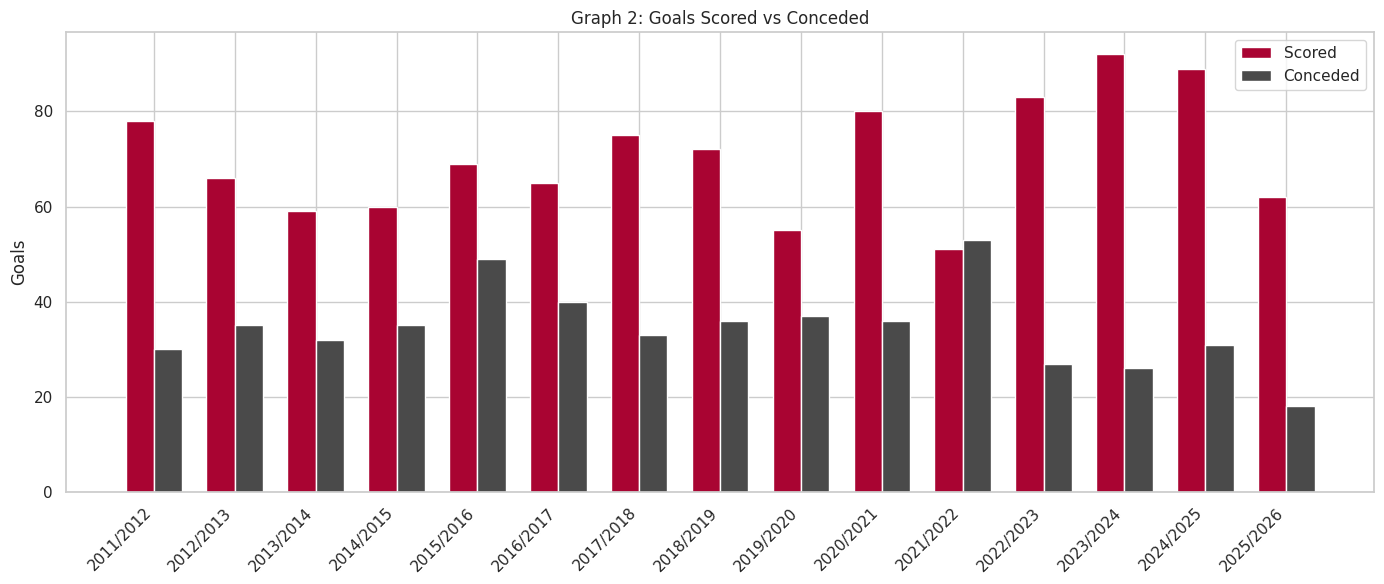

In [61]:
# Goals scored vs conceded
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(season_agg))
width = 0.35
ax.bar([i - width/2 for i in x], season_agg['goals_scored'], width, label='Scored', color=GS_RED)
ax.bar([i + width/2 for i in x], season_agg['goals_conceded'], width, label='Conceded', color='#4a4a4a')
ax.set_xticks(x)
ax.set_xticklabels(season_agg['season_label'], rotation=45, ha='right')
ax.set_ylabel('Goals')
ax.set_title('Graph 2: Goals Scored vs Conceded')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_goals.png', dpi=150)
plt.show()

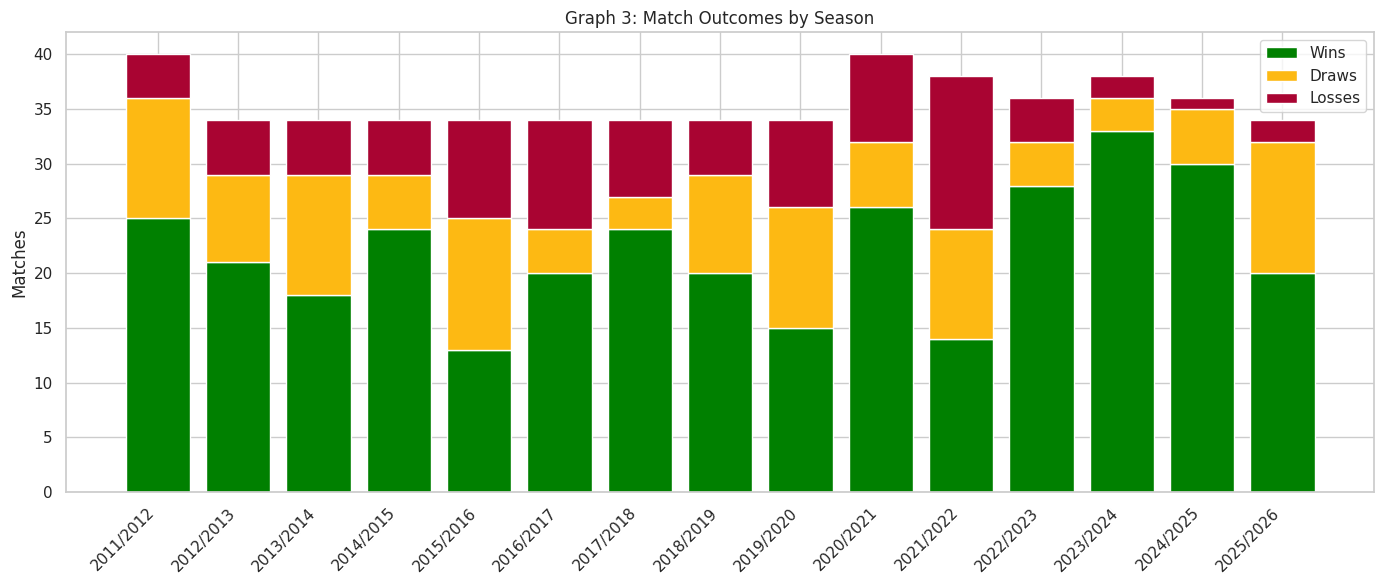

In [62]:
# Win/Draw/Loss stacked bar
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(season_agg))
ax.bar(x, season_agg['wins'], label='Wins', color='green')
ax.bar(x, season_agg['draws'], bottom=season_agg['wins'], label='Draws', color=GS_YELLOW)
ax.bar(x, season_agg['losses'], bottom=season_agg['wins'] + season_agg['draws'],
       label='Losses', color=GS_RED)
ax.set_xticks(x)
ax.set_xticklabels(season_agg['season_label'], rotation=45, ha='right')
ax.set_ylabel('Matches')
ax.set_title('Graph 3: Match Outcomes by Season')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_outcomes.png', dpi=150)
plt.show()

---
## Home vs Away Analysis

Galatasaray is famous worldwide for their fans and incredible home atmosphere. So one of the questions I want to answer is whether the home advantage is real, or how significant it is.

In [42]:
# Aggregate home vs away stats
venue_agg = df.groupby('venue_label').agg(
    matches=('fixture_id', 'count'),
    wins=('result', lambda x: (x == 'W').sum()),
    draws=('result', lambda x: (x == 'D').sum()),
    losses=('result', lambda x: (x == 'L').sum()),
    avg_gs_goals=('gs_goals', 'mean'),
    avg_opp_goals=('opp_goals', 'mean'),
    avg_possession=('gs_possession', 'mean'),
    avg_shots=('gs_shots', 'mean'),
    avg_shots_on=('gs_shots_on', 'mean'),
    avg_corners=('gs_corners', 'mean'),
    avg_fouls=('gs_fouls', 'mean'),
    total_points=('points', 'sum'),
).round(2)
#we selected several variables to look home vs away, and we grouped those by venue label.
venue_agg['win_rate'] = (venue_agg['wins'] / venue_agg['matches'] * 100).round(1)
venue_agg

,matches,wins,draws,losses,avg_gs_goals,avg_opp_goals,avg_possession,avg_shots,avg_shots_on,avg_corners,avg_fouls,total_points,win_rate
venue_label,,,,,,,,,,,,,
Away,267,139,66,62,1.74,1.08,57.14,13.81,5.03,5.23,11.73,483,52.1
Home,267,192,48,27,2.27,0.89,59.43,17.47,6.61,6.63,12.06,624,71.9


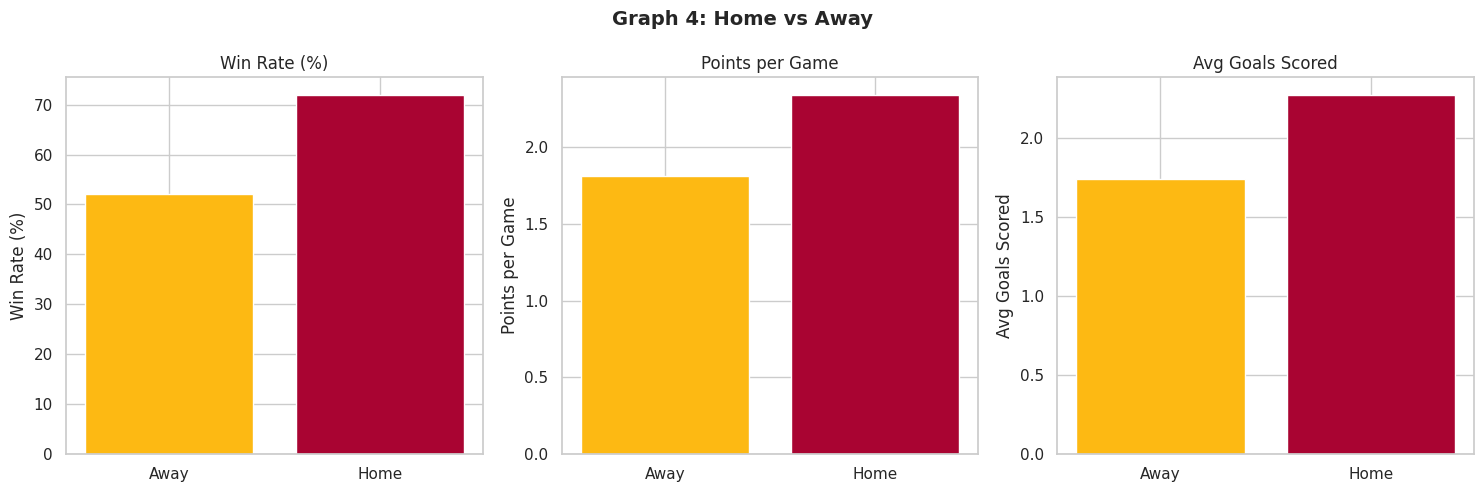

In [64]:
# Home vs away: goals, PPG, win rate
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

venue_agg['win_rate'] = (venue_agg['wins'] / venue_agg['matches'] * 100).round(1)
venue_agg['ppg'] = (venue_agg['total_points'] / venue_agg['matches']).round(2)

for ax, col, title in zip(axes, ['win_rate', 'ppg', 'avg_gs_goals'],
                           ['Win Rate (%)', 'Points per Game', 'Avg Goals Scored']):
    ax.bar(['Away', 'Home'], venue_agg[col], color=[GS_YELLOW,GS_RED])
    ax.set_title(title)
    ax.set_ylabel(title)

plt.suptitle('Graph 4: Home vs Away', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_home_away.png', dpi=150)
plt.show()

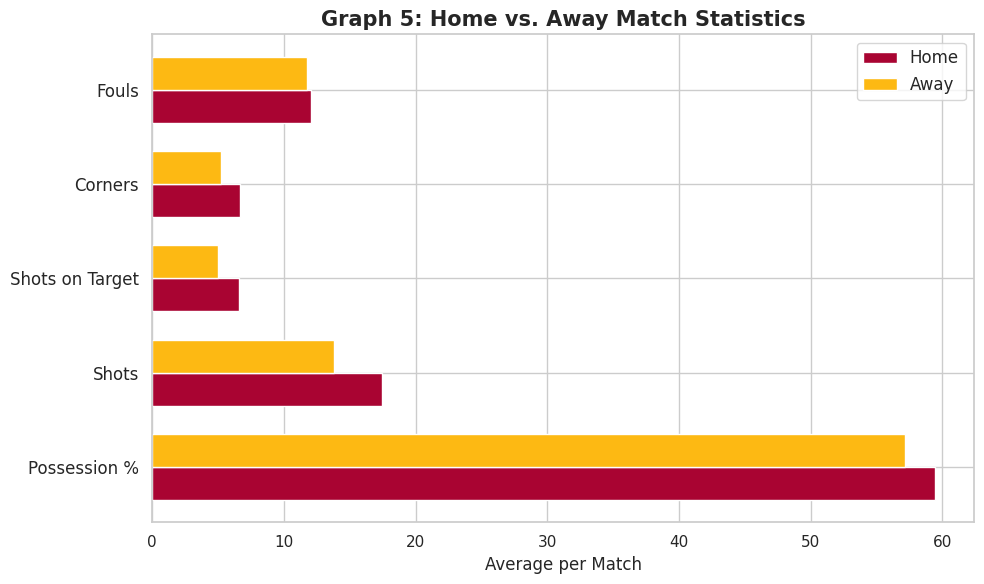

In [65]:
# Figure 6: Home vs Away — Match statistics radar-style comparison
# Using a grouped horizontal bar chart for clarity

compare_cols = ['avg_possession', 'avg_shots', 'avg_shots_on', 'avg_corners', 'avg_fouls']
compare_labels = ['Possession %', 'Shots', 'Shots on Target', 'Corners', 'Fouls']

home_vals = [venue_agg.loc['Home', c] for c in compare_cols]
away_vals = [venue_agg.loc['Away', c] for c in compare_cols]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(compare_labels))
height = 0.35

ax.barh(y - height/2, home_vals, height, label='Home', color=GS_RED)
ax.barh(y + height/2, away_vals, height, label='Away', color=GS_YELLOW)

ax.set_yticks(y)
ax.set_yticklabels(compare_labels, fontsize=12)
ax.set_xlabel('Average per Match', fontsize=12)
ax.legend(fontsize=12)
ax.set_title('Graph 5: Home vs. Away Match Statistics',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_home_away_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
from scipy import stats

# Variables to test: home vs away
test_cols = ['points', 'gs_goals', 'gs_shots', 'gs_shots_on', 'gs_possession', 'gs_corners', 'gs_fouls']

print('Table 2: t-test: Home vs Away\n')
print(f'{"Variable":<20} {"Home Mean":>10} {"Away Mean":>10} {"t-stat":>10} {"p-value":>10} {"Significant?(1%)":>15}')
print('-' * 80)

for col in test_cols:
    home = df[df['is_home']][col].dropna()
    away = df[~df['is_home']][col].dropna()
    t_stat, p_value = stats.ttest_ind(home, away)
    sig = 'Yes' if p_value < 0.01 else 'No'
    print(f'{col:<20} {home.mean():>10.3f} {away.mean():>10.3f} {t_stat:>10.3f} {p_value:>10.4f} {sig:>15}')

Table 2: t-test: Home vs Away

Variable              Home Mean  Away Mean     t-stat    p-value Significant?(1%)
--------------------------------------------------------------------------------
points                    2.337      1.809      5.102     0.0000             Yes
gs_goals                  2.269      1.744      4.304     0.0000             Yes
gs_shots                 17.466     13.815      6.367     0.0000             Yes
gs_shots_on               6.611      5.032      5.550     0.0000             Yes
gs_possession            59.430     57.138      2.789     0.0056             Yes
gs_corners                6.630      5.228      4.445     0.0000             Yes
gs_fouls                 12.057     11.730      0.610     0.5424              No


---
##Rivalry Deep Dive

In [67]:
# Identify rival
#There rivals are the other 3 most successful Turkish clubs.
def get_rival(opponent):
    opp = str(opponent).lower()
    if 'fenerbahce' in opp or 'fenerbahçe' in opp:
        return 'Fenerbahçe'
    elif 'besiktas' in opp or 'beşiktaş' in opp or 'besikta' in opp:
        return 'Beşiktaş'
    elif 'trabzonspor' in opp:
        return 'Trabzonspor'
    return 'Other'

derbies = df[df['is_derby']].copy()
derbies['rival'] = derbies['opponent'].apply(get_rival)

# Head-to-head record
h2h = derbies.groupby('rival').agg(
    matches=('fixture_id', 'count'),
    wins=('result', lambda x: (x == 'W').sum()),
    draws=('result', lambda x: (x == 'D').sum()),
    losses=('result', lambda x: (x == 'L').sum()),
    goals_scored=('gs_goals', 'sum'),
    goals_conceded=('opp_goals', 'sum'),
).reset_index()
print('Table 3: Rivalry Summary')
h2h['win_rate'] = (h2h['wins'] / h2h['matches'] * 100).round(1)
h2h

Table 3: Rivalry Summary


,rival,matches,wins,draws,losses,goals_scored,goals_conceded,win_rate
0,Beşiktaş,32,16,6,10,44.0,34.0,50.0
1,Fenerbahçe,32,9,14,9,31.0,27.0,28.1
2,Trabzonspor,32,15,9,8,49.0,36.0,46.9


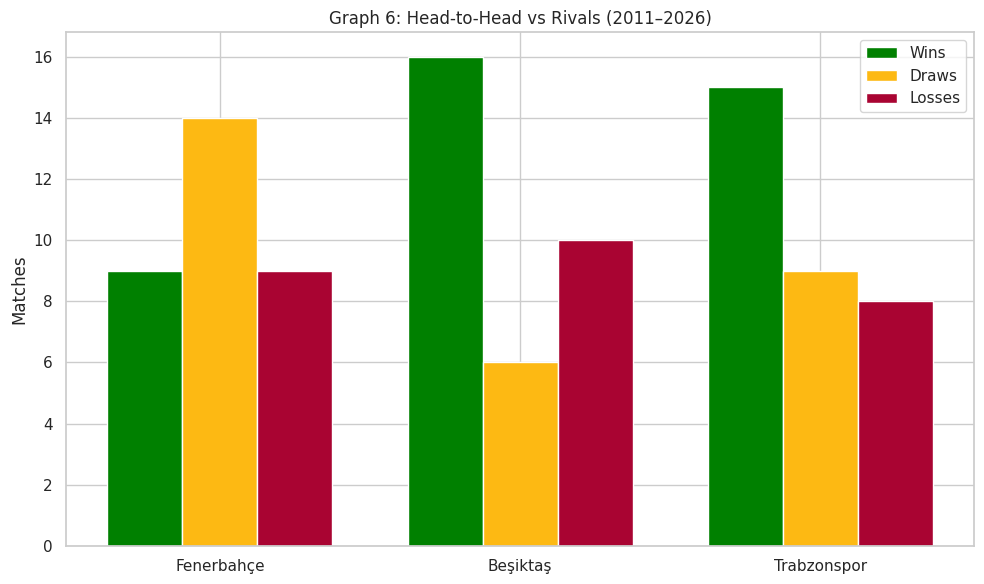

In [71]:
# Rivalry results
fig, ax = plt.subplots(figsize=(10, 6))
rivals_order = ['Fenerbahçe', 'Beşiktaş', 'Trabzonspor']
h2h_plot = h2h.set_index('rival').reindex(rivals_order)
x = range(len(rivals_order))
w = 0.25

ax.bar([i - w for i in x], h2h_plot['wins'], w, label='Wins', color='green')
ax.bar(x, h2h_plot['draws'], w, label='Draws', color=GS_YELLOW)
ax.bar([i + w for i in x], h2h_plot['losses'], w, label='Losses', color=GS_RED)
ax.set_xticks(x)
ax.set_xticklabels(rivals_order)
ax.set_ylabel('Matches')
ax.set_title('Graph 6: Head-to-Head vs Rivals (2011–2026)')
ax.legend()
plt.tight_layout()
plt.savefig('fig8_rivals.png', dpi=150)
plt.show()

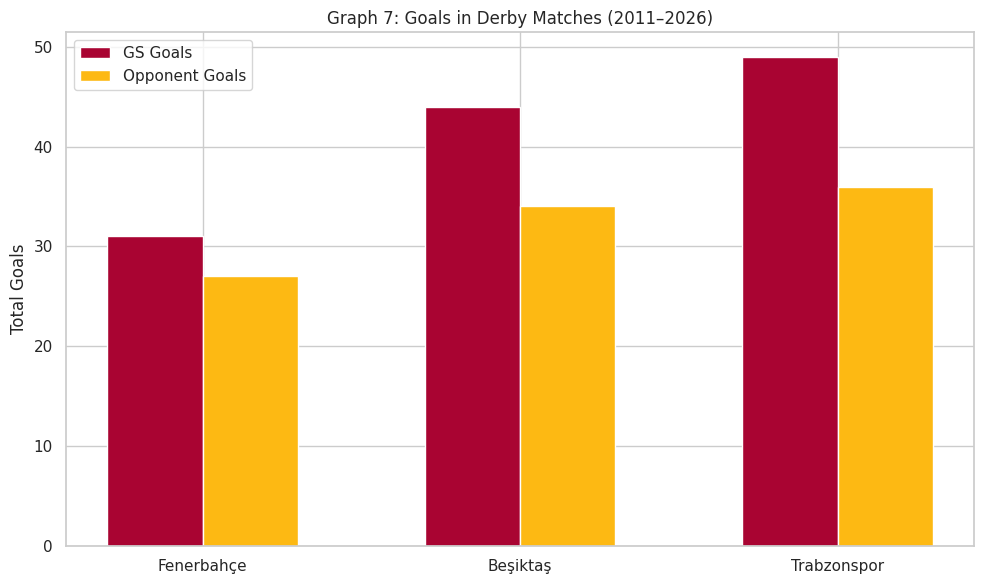

In [70]:
# Derby goals
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(rivals_order))
w = 0.3
ax.bar([i - w/2 for i in x], h2h_plot['goals_scored'], w, label='GS Goals', color=GS_RED)
ax.bar([i + w/2 for i in x], h2h_plot['goals_conceded'], w, label='Opponent Goals', color=GS_YELLOW)
ax.set_xticks(x)
ax.set_xticklabels(rivals_order)
ax.set_ylabel('Total Goals')
ax.set_title('Graph 7: Goals in Derby Matches (2011–2026)')
ax.legend()
plt.tight_layout()
plt.savefig('fig9_derby_goals.png', dpi=150)
plt.show()

---
## 7. Player Contributions

In [ ]:
# Clean player data
players = players_df.copy()
players['rating'] = pd.to_numeric(players['rating'], errors='coerce')
players['goals'] = pd.to_numeric(players['goals'], errors='coerce').fillna(0).astype(int)
players['assists'] = pd.to_numeric(players['assists'], errors='coerce').fillna(0).astype(int)
players['minutes'] = pd.to_numeric(players['minutes'], errors='coerce').fillna(0).astype(int)
players['appearances'] = pd.to_numeric(players['appearances'], errors='coerce').fillna(0).astype(int)
players['age'] = pd.to_numeric(players['age'], errors='coerce')
players['goal_contributions'] = players['goals'] + players['assists']
players['season_label'] = players['season'].apply(lambda x: f'{x}/{x+1}')

print(f'{len(players)} player records, {players["name"].nunique()} unique players')

638 player records, 242 unique players


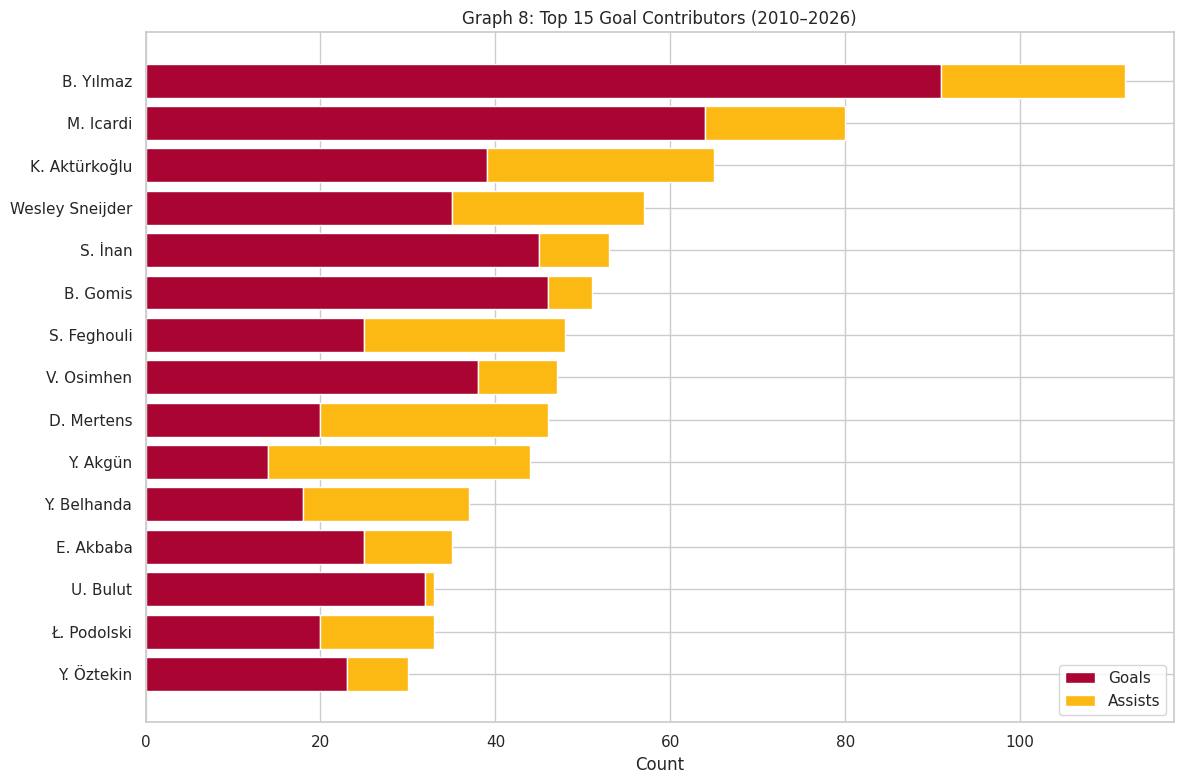

In [80]:
# Top 15 goal contributors
top = (players.groupby('name')
    .agg(goals=('goals', 'sum'), assists=('assists', 'sum'), gc=('goal_contributions', 'sum'))
    .sort_values('gc', ascending=True)
    .tail(15))

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top.index, top['goals'], label='Goals', color=GS_RED)
ax.barh(top.index, top['assists'], left=top['goals'], label='Assists', color=GS_YELLOW)
ax.set_xlabel('Count')
ax.set_title('Graph 8: Top 15 Goal Contributors (2010–2026)')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_top_contributors.png', dpi=150)
plt.show()

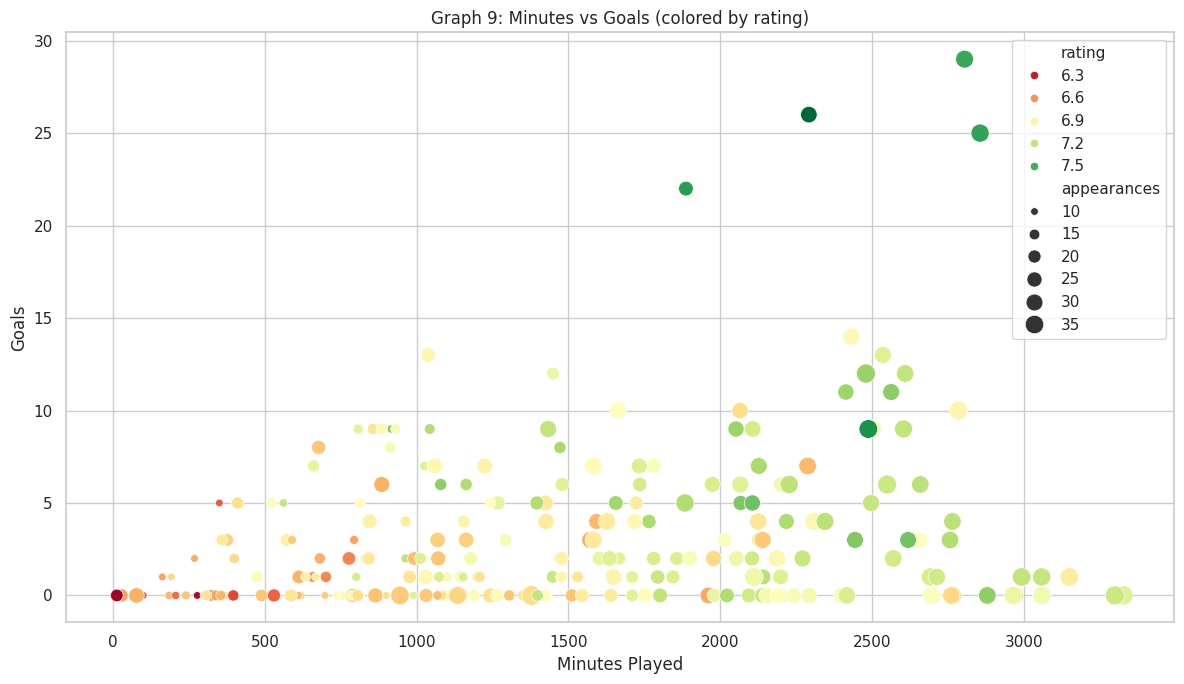

In [81]:
# Minutes vs goals scatter
#It is important to note that this is per season rating, not combined for all seasons.
qualified = players[players['appearances'] >= 10]
plt.figure(figsize=(12, 7))
sns.scatterplot(data=qualified, x='minutes', y='goals',
                hue='rating', palette='RdYlGn', size='appearances',
                sizes=(30, 200))
plt.xlabel('Minutes Played')
plt.ylabel('Goals')
plt.title('Graph 9: Minutes vs Goals (colored by rating)')
plt.tight_layout()
plt.savefig('fig11_minutes_goals.png', dpi=150)
plt.show()

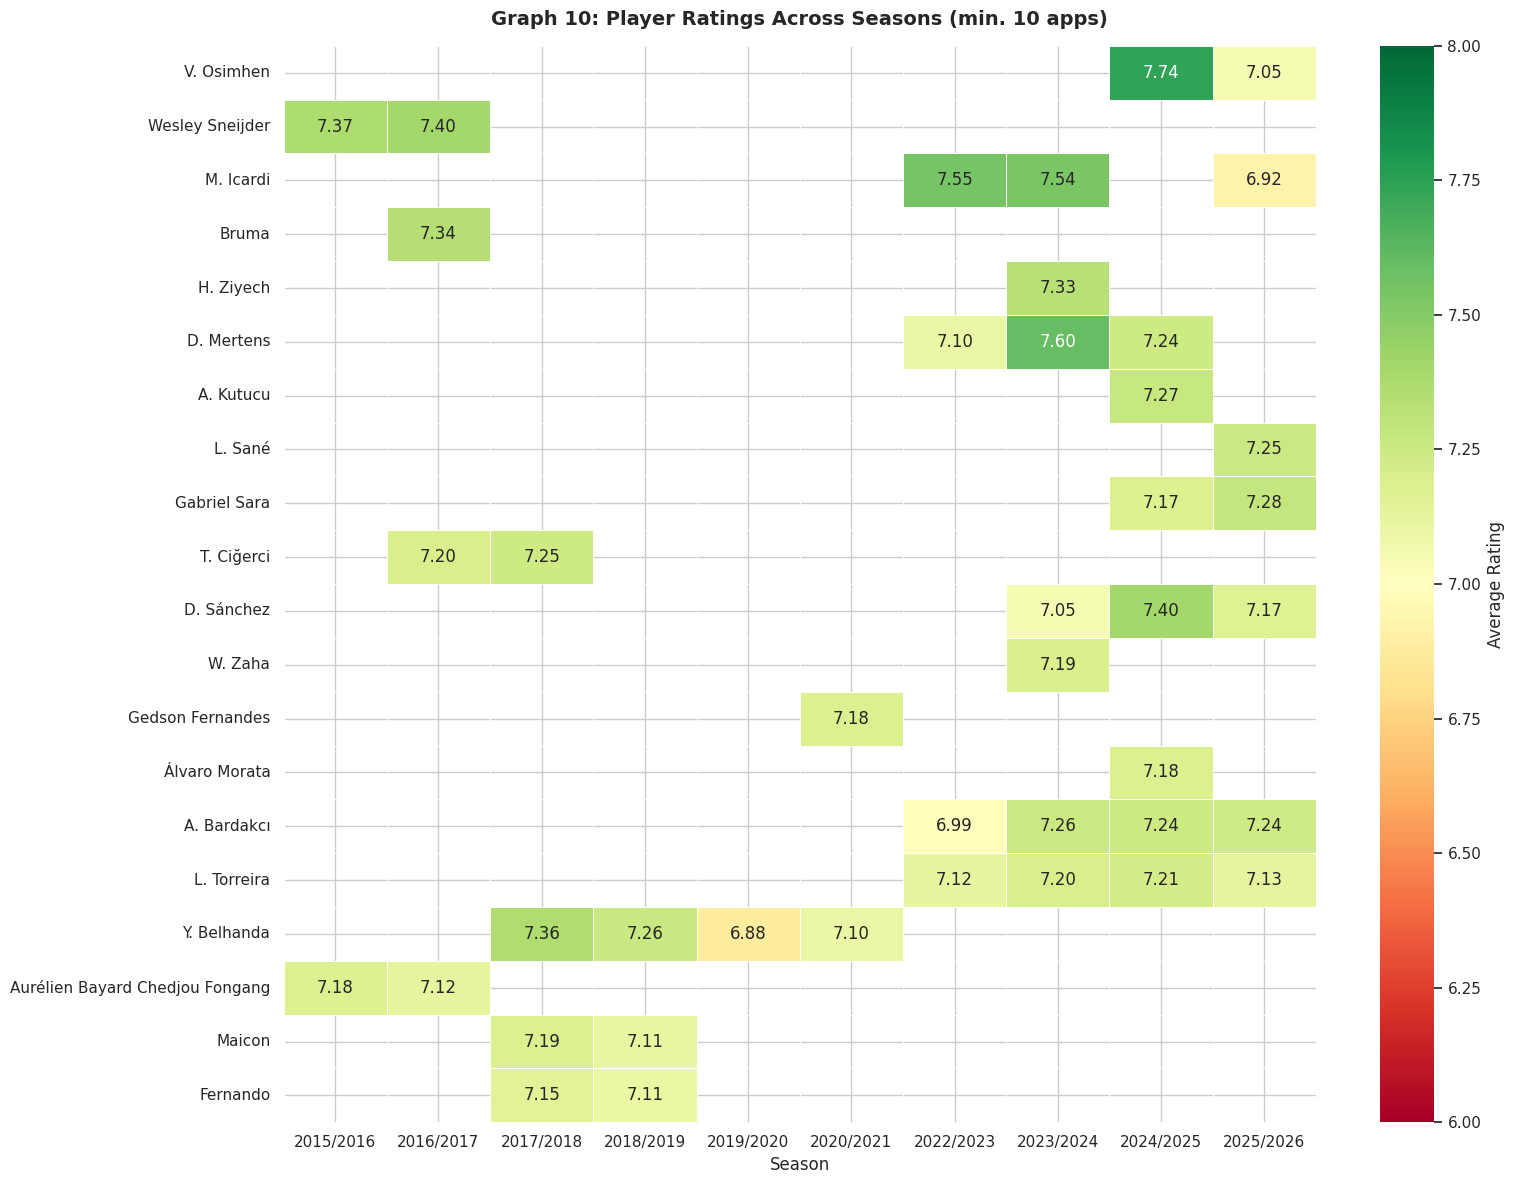

In [82]:
#Top rated players (min 10 appearances) per season — heatmap
qualified_rated = players[(players['appearances'] >= 10) & (players['rating'].notna())].copy()

# Pivot: player × season
top_rated_names = (qualified_rated.groupby('name')['rating'].mean()
                   .nlargest(20).index.tolist())
pivot = qualified_rated[qualified_rated['name'].isin(top_rated_names)].pivot_table(
    index='name', columns='season_label', values='rating'
)
#highest rated first
pivot = pivot.reindex(pivot.mean(axis=1).sort_values(ascending=False).index)
#this is a quite complicated plot
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
            ax=ax, vmin=6.0, vmax=8.0, cbar_kws={'label': 'Average Rating'})
ax.set_title('Graph 10: Player Ratings Across Seasons (min. 10 apps)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('')
ax.set_xlabel('Season', fontsize=12)

plt.tight_layout()
plt.savefig('fig12_player_ratings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

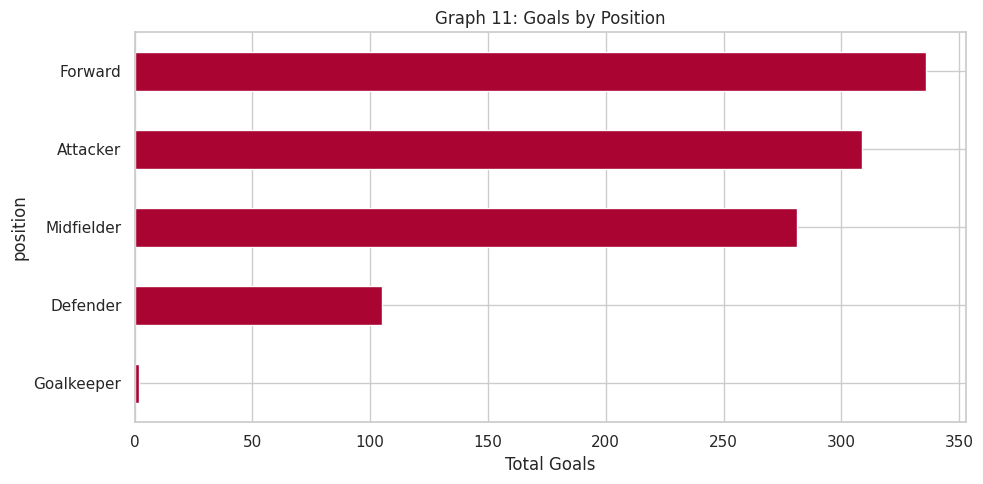

In [83]:
# Goals by position
plt.figure(figsize=(10, 5))
pos_goals = players.groupby('position')['goals'].sum().sort_values()
pos_goals.plot(kind='barh', color=GS_RED)
plt.xlabel('Total Goals')
plt.title('Graph 11: Goals by Position')
plt.tight_layout()
plt.savefig('fig12_position_goals.png', dpi=150)
plt.show()

In [49]:
# Collect goal events (1 API call per match)
all_goals = []

for fid in fixtures_df['fixture_id']:
    url = f'{BASE_URL}/fixtures/events'
    response = requests.get(url, headers=HEADERS, params={'fixture': fid})
    events = response.json()['response']

    for e in events:
        if e['type'] == 'Goal':
            all_goals.append({
                'fixture_id': fid,
                'minute': e['time']['elapsed'],
                'team': e['team']['name'],
                'player': e['player']['name'],
            })
    time.sleep(0.3)

goals_df = pd.DataFrame(all_goals)
goals_df['is_gs'] = goals_df['team'].str.contains('Galatasaray', case=False, na=False)
goals_df['type'] = goals_df['is_gs'].map({True: 'Scored', False: 'Conceded'})

print(f'Collected {len(goals_df)} goals')
goals_df.head()

Collected 1557 goals


,fixture_id,minute,team,player,is_gs,type
0,509614,26,Galatasaray,Felipe Melo,True,Scored
1,509614,79,Galatasaray,A. Yilmaz,True,Scored
2,509616,17,Fenerbahce,R. Ziegler,False,Conceded
3,509616,68,Galatasaray,S. Inan,True,Scored
4,509616,79,Fenerbahce,M. Stoch,False,Conceded


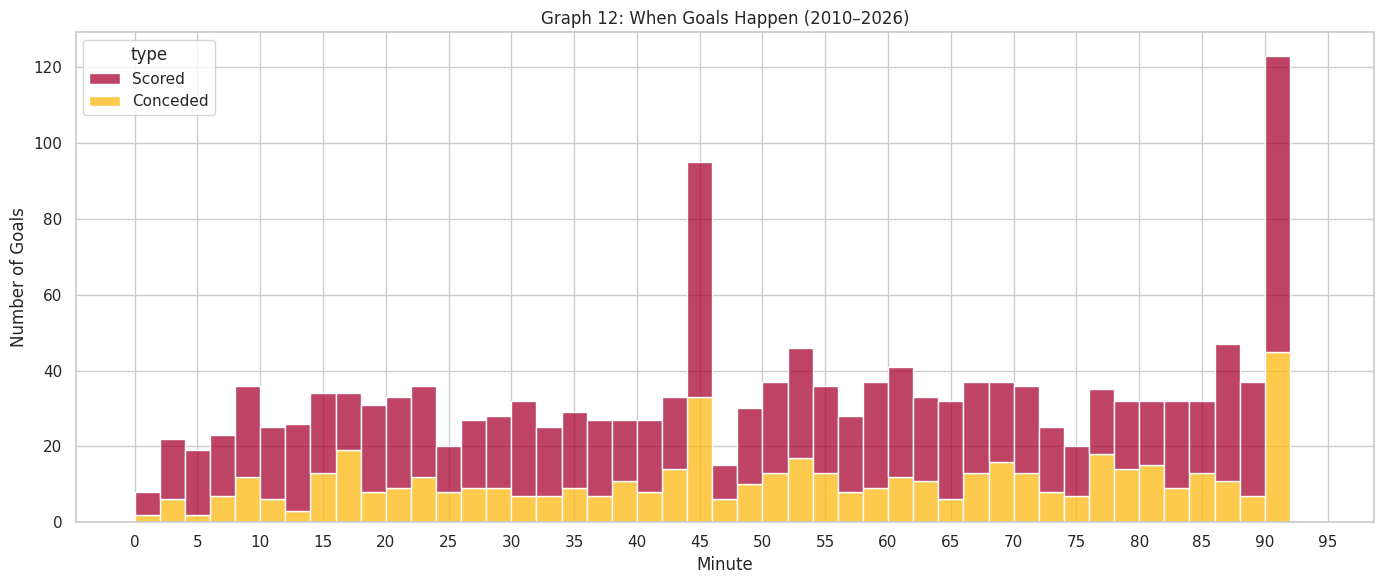

In [84]:
# Goals by minute
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(data=goals_df, x='minute', hue='type', bins=range(0, 96, 2),
             palette={'Scored': GS_RED, 'Conceded': GS_YELLOW}, ax=ax,
             multiple='stack')
ax.set_xlabel('Minute')
ax.set_ylabel('Number of Goals')
ax.set_title('Graph 12: When Goals Happen (2010–2026)')
ax.set_xticks(range(0, 96, 5))
plt.tight_layout()
plt.savefig('fig_goal_minutes.png', dpi=150)
plt.show()

---
## 8. Correlation Analysis

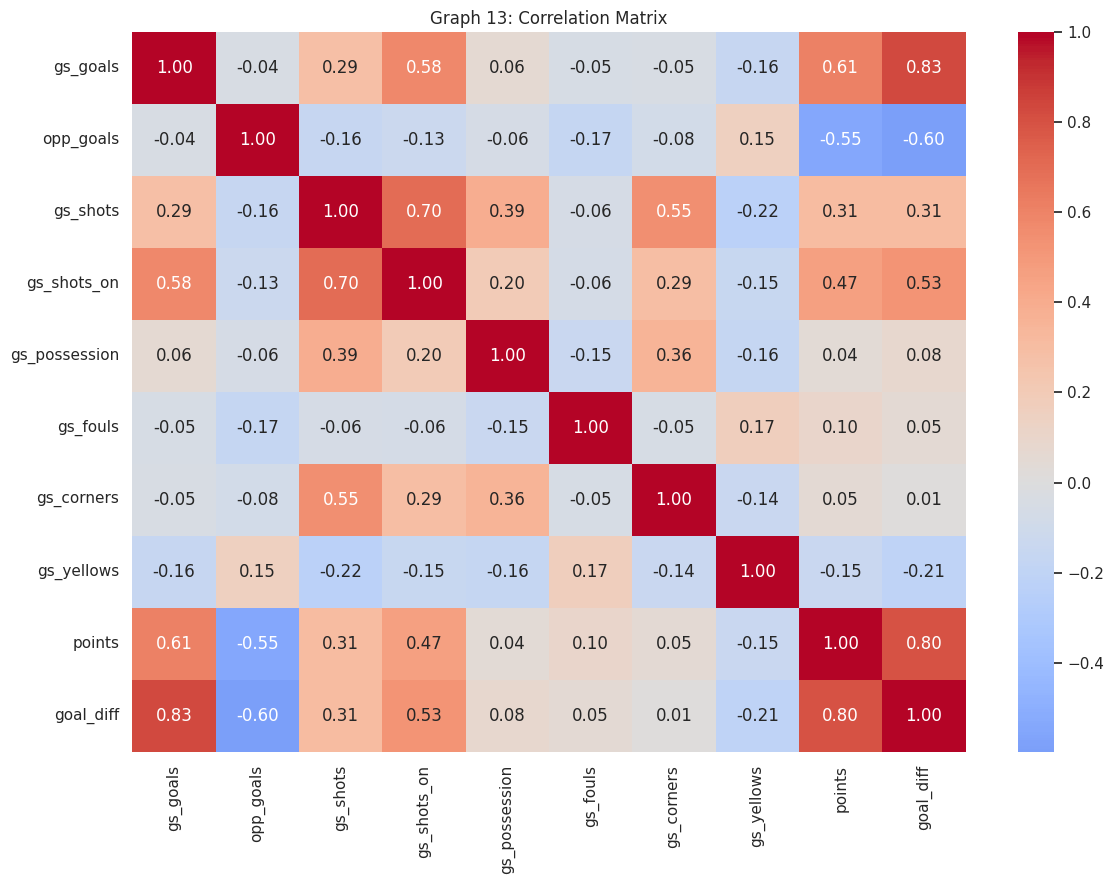

In [85]:
# Correlation heatmap
corr_cols = ['gs_goals', 'opp_goals', 'gs_shots', 'gs_shots_on', 'gs_possession',
             'gs_fouls', 'gs_corners', 'gs_yellows', 'points', 'goal_diff']
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(12, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Graph 13: Correlation Matrix')
plt.tight_layout()
plt.savefig('fig13_correlation.png', dpi=150)
plt.show()

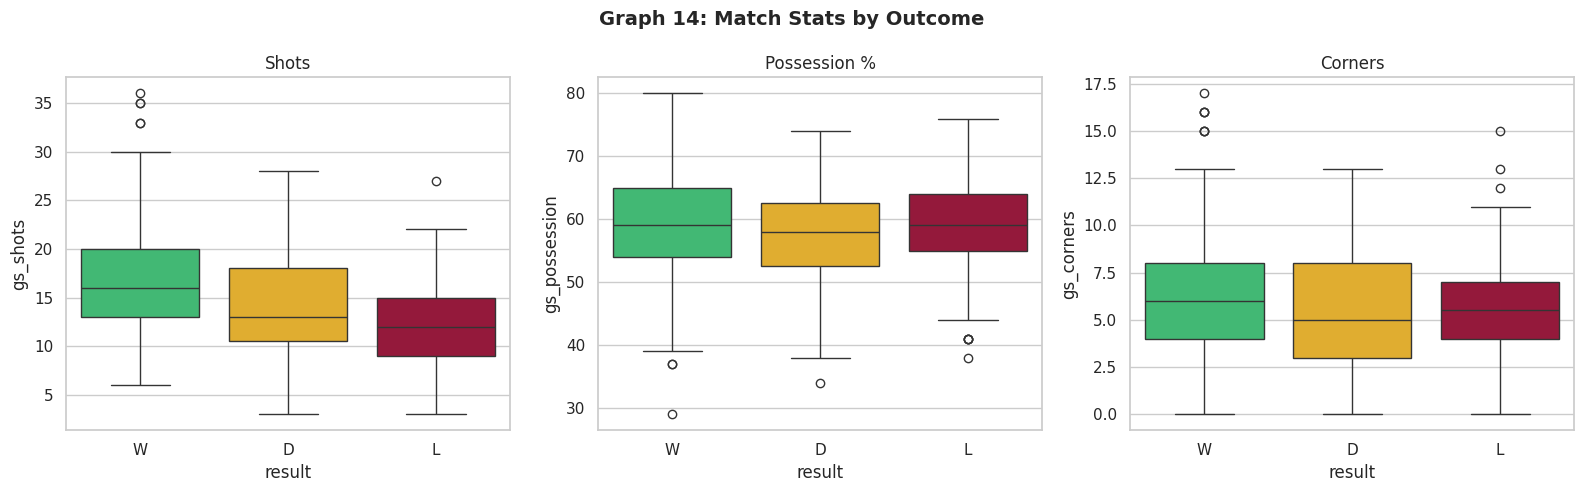

In [93]:
# Key stats by match result
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = {'W': '#2ecc71', 'D': GS_YELLOW, 'L': GS_RED}

for ax, col, title in zip(axes, ['gs_shots', 'gs_possession', 'gs_corners'],
                           ['Shots', 'Possession %', 'Corners']):
    sns.boxplot(data=df, x='result', y=col, order=['W', 'D', 'L'],
               palette=palette, ax=ax,hue='result')
    ax.set_title(title)

plt.suptitle('Graph 14: Match Stats by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_stats_by_result.png', dpi=150)
plt.show()

In [87]:
# Halftime status from Galatasaray's perspective
df['ht_gs'] = df.apply(lambda r: r['ht_home'] if r['is_home'] else r['ht_away'], axis=1)
df['ht_opp'] = df.apply(lambda r: r['ht_away'] if r['is_home'] else r['ht_home'], axis=1)

df['ht_status'] = df.apply(
    lambda r: 'Winning' if r['ht_gs'] > r['ht_opp']
    else ('Losing' if r['ht_gs'] < r['ht_opp'] else 'Drawing'), axis=1)

# What happens after halftime?
ht_results = pd.crosstab(df['ht_status'], df['result'], normalize='index').round(3) * 100
ht_results = ht_results[['W', 'D', 'L']]
ht_results.columns = ['Win %', 'Draw %', 'Loss %']
print('Table 4: Final Result by Halftime Status')
ht_results

Table 4: Final Result by Halftime Status


,Win %,Draw %,Loss %
ht_status,,,
Drawing,44.6,33.3,22.1
Losing,27.4,26.2,46.4
Winning,89.9,8.9,1.3


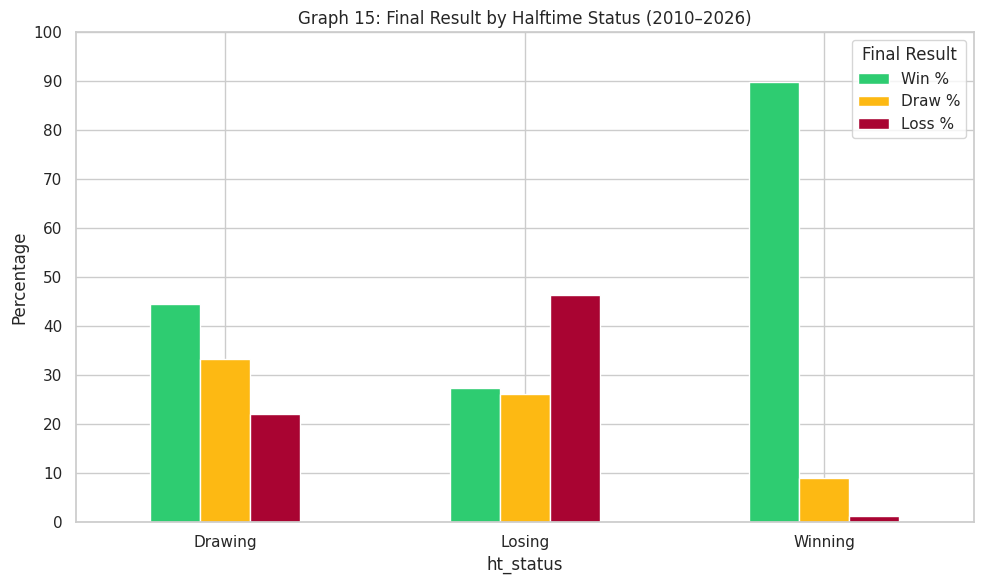

In [89]:
# Visualize it
fig, ax = plt.subplots(figsize=(10, 6))
ht_results.plot(kind='bar', ax=ax, color=['#2ecc71', GS_YELLOW, GS_RED])
ax.set_ylabel('Percentage')
ax.set_title('Graph 15: Final Result by Halftime Status (2010–2026)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Final Result')
ax.set_yticks(range(0, 101, 10))
plt.tight_layout()
plt.savefig('fig_halftime.png', dpi=150)
plt.show()

---
## 10. Do Champions Finish Stronger?

We compare points per game in the final 10 matches vs the rest of the season,
split by whether Galatasaray won the title that year.

In [92]:
# Championship seasons (season = year the season started)
title_years = [2011, 2012, 2014, 2017, 2018, 2022, 2023, 2024]

# Label final 10 matches per season
df_sorted = df.sort_values(['season', 'date']).copy()

def label_stretch(group_df):
    # Initialize all matches as 'Rest of Season'
    stretch_labels = pd.Series('Rest of Season', index=group_df.index)
    # Label the last 10 matches as 'Final 10 Matches'
    if len(group_df) >= 10: # Ensure there are enough rows for the last 10
        stretch_labels.iloc[-10:] = 'Final 10 Matches'
    return stretch_labels

# Apply the function to each season group to create the 'stretch' column
df_sorted['stretch'] = df_sorted.groupby('season', group_keys=False).apply(label_stretch)
df_sorted['season_type'] = df_sorted['season'].isin(title_years).map(
    {True: 'Champion', False: 'Non-Champion'}
)

# Compare
stretch_agg = df_sorted.groupby(['season_type', 'stretch']).agg(
    ppg=('points', 'mean'),
    win_rate=('result', lambda x: (x == 'W').mean() * 100),
).round(2)

print('Table 5')
stretch_agg

Table 5


/tmp/ipykernel_47275/3579529773.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sorted['stretch'] = df_sorted.groupby('season', group_keys=False).apply(label_stretch)


ppg  win_rate
season_type  stretch                         
Champion     Final 10 Matches  2.41     76.25
             Rest of Season    2.28     69.90
Non-Champion Final 10 Matches  1.57     41.43
             Rest of Season    1.88     54.49

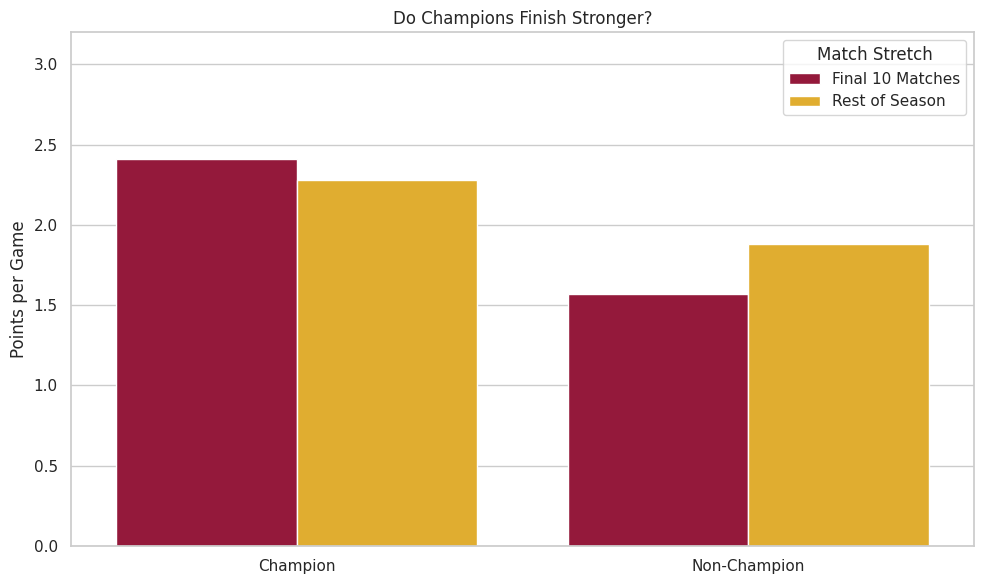

In [ ]:
# Final stretch comparison
stretch_plot = stretch_agg.reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Final 10 Matches': GS_RED,'Rest of Season': GS_YELLOW}

sns.barplot(
    data=stretch_plot,
    x='season_type',
    y='ppg',
    hue='stretch',
    palette=colors,
    ax=ax
)

ax.set_xlabel('') # Clear x-axis label as 'season_type' is self-explanatory
ax.set_ylabel('Points per Game')
ax.set_title('Do Champions Finish Stronger?')
ax.set_ylim(0, 3.2)
ax.legend(title='Match Stretch')
plt.tight_layout()
plt.savefig('fig17_final_stretch.png', dpi=150)
plt.show()